# SOM als Farbkarte — Einheitswürfel [0,1]³

Gleichverteilte Samples aus dem 3D-Einheitswürfel werden als RGB-Farben interpretiert.
Das SOM ordnet die Farbpalette topologisch auf einem 2D-Grid an — ähnliche Farben
landen auf benachbarten Neuronen.

Da die Eingabedaten bereits in [0,1]³ liegen, sind die gelernten Gewichtsvektoren
direkt als RGB-Farben interpretierbar — ohne PCA-Projektion.


In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

from dbgsom.SomVQ import SomVQ

rng = np.random.default_rng(42)
X = rng.uniform(0, 1, size=(10000, 3))

print(f"Trainingsdaten: {X.shape}  (N Samples × 3 RGB-Kanäle)")

Trainingsdaten: (10000, 3)  (N Samples × 3 RGB-Kanäle)


## Training


In [2]:
som = SomVQ(
    lambda_=1.5,
    n_iter=10000,
    max_neurons=200,
    sigma_end=1,
    random_state=4,
    verbose=True,
)
som.fit(X)

 50%|█████     | 5001/10000 [01:57<01:57, 42.69 epochs/s]


,n_iter,10000
,spreading_factor,0.99
,sigma_end,1
,verbose,True
,random_state,4
,max_neurons,200
,sigma_start,None
,sigma_fine,None
,vertical_growth,False
,decay_function,'exponential'
,neighborhood_function,'gaussian'


In [3]:
som.converged_

True

In [4]:
print(f"Neuronen:             {som.som_.number_of_nodes()}")
print(f"Quantisierungsfehler: {som.quantization_error_:.4f}")
print(f"Topografischer Fehler:{som.topographic_error_:.4f}")

Neuronen:             213
Quantisierungsfehler: 0.1500
Topografischer Fehler:0.1917


## Visualisierung


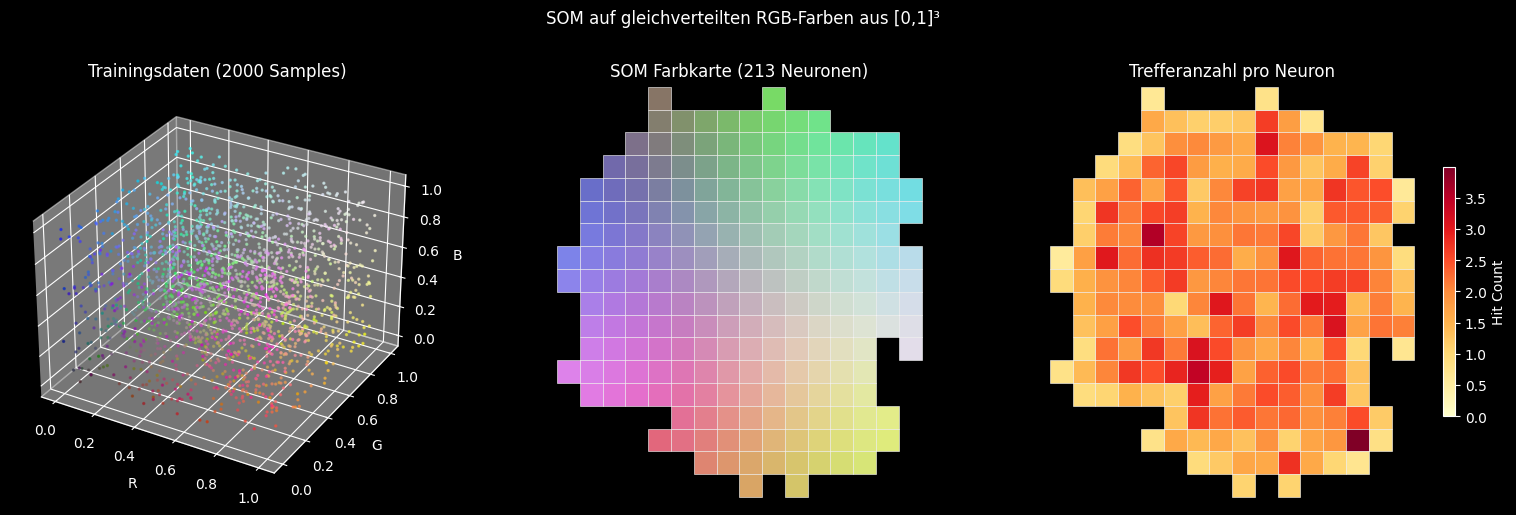

In [5]:
def plot_color_grid(som, ax=None):
    """Render the SOM grid; each tile is coloured by the neuron's weight vector.

    sqrt() applies gamma = 0.5 correction so perceived brightness matches
    the linear RGB values (avoids dark colours appearing almost black).
    """
    if ax is None:
        _, ax = plt.subplots()
    node_to_w = {n: som.weights_[i] for i, n in enumerate(som.neurons_)}
    rows = [n[0] for n in som.neurons_]
    cols = [n[1] for n in som.neurons_]
    for node in som.neurons_:
        color = np.sqrt(np.clip(node_to_w[node], 0, 1))
        rect = patches.Rectangle(
            (node[1], node[0]),
            1,
            1,
            facecolor=color,
            edgecolor="white",
            linewidth=0.4,
        )
        ax.add_patch(rect)
    ax.set_xlim(min(cols) - 0.1, max(cols) + 1.1)
    ax.set_ylim(min(rows) - 0.1, max(rows) + 1.1)
    ax.set_aspect("equal")
    ax.axis("off")


fig = plt.figure(figsize=(16, 5))

# --- 3-D Scatter der Trainingsdaten ---
ax3d = fig.add_subplot(131, projection="3d")
idx = rng.choice(len(X), size=2000, replace=False)
ax3d.scatter(
    X[idx, 0],
    X[idx, 1],
    X[idx, 2],
    c=np.sqrt(X[idx]),
    s=2,
    alpha=0.6,
)
ax3d.set_xlabel("R")
ax3d.set_ylabel("G")
ax3d.set_zlabel("B")
ax3d.set_title("Trainingsdaten (2000 Samples)")

# --- SOM-Grid eingefärbt durch Gewichtsvektoren ---
ax_grid = fig.add_subplot(132)
plot_color_grid(som, ax=ax_grid)
ax_grid.set_title(f"SOM Farbkarte ({som.som_.number_of_nodes()} Neuronen)")

# --- Hit-Count-Karte ---
ax_hit = fig.add_subplot(133)
node_to_hits = {n: som.som_.nodes[n]["density"] for n in som.neurons_}
rows = [n[0] for n in som.neurons_]
cols = [n[1] for n in som.neurons_]
hit_vals = np.array([node_to_hits[n] for n in som.neurons_], dtype=float)
hit_norm = hit_vals / hit_vals.max()
cmap = plt.cm.YlOrRd
for node, h in zip(som.neurons_, hit_norm):
    rect = patches.Rectangle(
        (node[1], node[0]),
        1,
        1,
        facecolor=cmap(h),
        edgecolor="white",
        linewidth=0.4,
    )
    ax_hit.add_patch(rect)
ax_hit.set_xlim(min(cols) - 0.1, max(cols) + 1.1)
ax_hit.set_ylim(min(rows) - 0.1, max(rows) + 1.1)
ax_hit.set_aspect("equal")
ax_hit.axis("off")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, hit_vals.max()))
plt.colorbar(sm, ax=ax_hit, shrink=0.6, label="Hit Count")
ax_hit.set_title("Trefferanzahl pro Neuron")

plt.suptitle("SOM auf gleichverteilten RGB-Farben aus [0,1]³", y=1.01)
plt.tight_layout()
plt.show()

## Nachbarschafts-Konsistenz

Für jedes Neuronenpaar, das auf dem Grid adjazent ist, berechnen wir den
euklidischen Abstand ihrer Gewichtsvektoren. Ein gut geordnetes SOM hat
kleine Abstände zwischen Nachbarn — das ist die Grundlage des topografischen Fehlers.


In [6]:
neighbor_dists = [
    np.linalg.norm(som.som_.nodes[u]["weight"] - som.som_.nodes[v]["weight"])
    for u, v in som.som_.edges()
]

print(f"Mittlerer Nachbar-Abstand im Gewichtsraum: {np.mean(neighbor_dists):.4f}")
print(f"Max. Nachbar-Abstand:                      {np.max(neighbor_dists):.4f}")
print(f"(Zum Vergleich: Diagonale des Würfels = {np.sqrt(3):.4f})")

Mittlerer Nachbar-Abstand im Gewichtsraum: 0.0783
Max. Nachbar-Abstand:                      0.1067
(Zum Vergleich: Diagonale des Würfels = 1.7321)
